# Test-set submission

**Reads:** `models/<experiment>/` (frozen) or `runs/<run_id>/`, the test images, the assignment's
`Project_1-InputOutput.csv` and `Project_1-data_dict.csv` · **Writes:** `submission/`.

Predicts one `class_id` per test image with one trained model and fills our group's column (`404`)
of the submission sheet. Nothing here trains, and the whole notebook runs in well under a minute, which
leaves plenty of the 30-minute window for checking and pasting.

**On the day:**

1. Unpack the test images so that `gt_path` resolves under `TEST_ROOT`. With the default, that is
   `assets/test-challenge/test_dataset/ts_img_001.jpg`. Put the sheet's `Project_1-InputOutput.csv`
   next to it (the default `TEMPLATE`).
2. Run all cells: `uv run jupyter nbconvert --to notebook --execute --inplace notebooks/05_submit.ipynb`.
3. Check §2's self-check and §3's missing-image count, then glance at §5.
4. Paste `submission/404_column.txt` into column `404` of the Google Sheet, from the first image row
   down. The rows are in the template's order.

| env var | default | effect |
| --- | --- | --- |
| `MODEL` | `stretch+augment` | a frozen model's name (`models/<name>/`) or any run id in §1's list |
| `TEST_ROOT` | `assets/test-challenge` | the folder that `gt_path` (`./test_dataset/...`) is relative to |
| `TEMPLATE` | `TEST_ROOT/Project_1-InputOutput.csv` | the submission sheet, downloaded as CSV |

`stretch+augment` is the model `04_train` selected (highest mean val macro-F1 over three seeds).
`stretch`, its no-augmentation control, is frozen as the fallback. Any other run on this machine can
be used by its id. See `thai_char_cnn.submit` for what freezing keeps and why.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from PIL import Image

from thai_char_cnn.data import load_split_images
from thai_char_cnn.paths import FONT, RAW, ROOT, SPLIT_DIR
from thai_char_cnn.submit import (
    IMAGE_SUFFIXES,
    list_candidates,
    load_candidate,
    load_class_ids,
    load_test_image,
    resolve_image,
)
from thai_char_cnn.train import current_split_id

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
font_manager.fontManager.addfont(str(FONT))
THAI = font_manager.FontProperties(fname=str(FONT), size=14)

GROUP = "404"                                   # our column in the submission sheet
MODEL = os.environ.get("MODEL", "stretch+augment")
CHALLENGE = ROOT / "assets" / "test-challenge"
TEST_ROOT = Path(os.environ.get("TEST_ROOT", CHALLENGE))
TEMPLATE = Path(os.environ.get("TEMPLATE", TEST_ROOT / "Project_1-InputOutput.csv"))
DATA_DICT = CHALLENGE / "Project_1-data_dict.csv"
OUT_DIR = ROOT / "submission"
N_RECENT = 10

print(f"group     : {GROUP}")
print(f"model     : {MODEL}")
print(f"test root : {TEST_ROOT}")
print(f"template  : {TEMPLATE}")

group     : 404
model     : stretch+augment
test root : /mnt/srv/home/whats/cnn/repo/assets/test-challenge
template  : /mnt/srv/home/whats/cnn/repo/assets/test-challenge/Project_1-InputOutput.csv


## 1 · Candidates

Frozen models first, then the most recently finished runs in `runs/`. Set `MODEL` to a `key`. A run
marked `usable=False` was trained on another split, so this checkout can't map its outputs to
classes. The val scores come from `04_train` and are optimistic (val also picked the epoch, the
experiment and the seed). Compare them only between runs on the same `split_id`.

In [2]:
cands = list_candidates(N_RECENT)
display(cands.round(4))

,source,key,name,run_id,seed,model,img_size,epochs,val_macro_f1,val_acc,train_version,split_id,updated,usable
0,frozen,stretch,stretch,c324b6b57c75,271,small_cnn,32,40,0.9907,0.9917,1.p2,d0a0d7ada85a,2026-09-25 05:50,True
1,frozen,stretch+augment,stretch+augment,c80f69cf5af9,137,small_cnn,32,40,0.9907,0.9892,1.p2,d0a0d7ada85a,2026-09-25 05:50,True
2,run,09a385b0ef4e,5,09a385b0ef4e,271,small_cnn,32,40,0.8212,0.8736,1.p2,d0a0d7ada85a,2026-09-25 04:33,True
3,run,34895c68f4dd,33,34895c68f4dd,137,small_cnn,32,40,0.7598,0.8338,1.p2,d0a0d7ada85a,2026-09-25 04:33,True
4,run,eb1b11feaed4,139,eb1b11feaed4,42,small_cnn,32,40,0.7955,0.8241,1.p2,d0a0d7ada85a,2026-09-25 04:33,True
5,run,1b14bcc35082,15,1b14bcc35082,271,resnet18,64,40,0.9860,0.9886,1.p2,d0a0d7ada85a,2026-09-25 04:33,True
6,run,2d2b12bb1706,31,2d2b12bb1706,137,resnet18,64,40,0.9845,0.9887,1.p2,d0a0d7ada85a,2026-09-25 04:29,True
7,run,eb932a8eba50,140,eb932a8eba50,42,resnet18,64,40,0.9889,0.9867,1.p2,d0a0d7ada85a,2026-09-25 04:25,True
8,run,a0bd273a4f34,103,a0bd273a4f34,271,small_cnn,32,40,0.9861,0.9879,1.p2,d0a0d7ada85a,2026-09-25 04:20,True
9,run,a9c0d3f47e2c,110,a9c0d3f47e2c,137,small_cnn,32,40,0.9855,0.9892,1.p2,d0a0d7ada85a,2026-09-25 04:18,True


## 2 · Load the model and check it

**Self-check:** re-predict every val image of the current split and compare the accuracy with the one
`04_train` recorded for this run. The two must agree: a gap means test images are not being
preprocessed the way training images were. It runs only when the model was trained on the current
split and `raw/` is on this machine.

In [3]:
pred = load_candidate(MODEL)
meta = pred.meta
print(f"loaded    : {pred.source}  on {pred.device}")
print(f"run       : {meta['run_id']}  seed {meta['seed']}  split {meta['split_id']}  train_version {meta['train_version']}")
print(f"input     : {pred.cfg['model']} · {pred.cfg['img_size']} px · {pred.cfg['preprocess']}")
print(f"val       : macro-F1 {meta['val_macro_f1']:.4f}  accuracy {meta['val_acc']:.4f}")

class_ids = load_class_ids(DATA_DICT)
missing = sorted(set(pred.classes.folder) - set(class_ids))
assert not missing, f"model classes with no class_id in the data dictionary: {missing}"
idx_to_id = pred.classes.folder.map(class_ids).to_numpy()      # class_idx -> 3-digit class_id
print(f"classes   : {len(idx_to_id)} model outputs, all mapped to a class_id")

if meta["split_id"] == current_split_id() and RAW.exists():
    val = load_split_images(SPLIT_DIR).query("split == 'val'")
    acc = float((pred.predict([RAW / p for p in val.path]).argmax(1).numpy() == val.class_idx.to_numpy()).mean())
    print(f"self-check: val accuracy {acc:.4f} re-predicted vs {meta['val_acc']:.4f} recorded ({len(val):,} images, {pred.inverted.sum()} inverted)")
    assert abs(acc - meta["val_acc"]) < 1e-3, "re-predicted val accuracy differs: preprocessing mismatch"
else:
    print("self-check: skipped (model is on another split, or raw/ is not on this machine)")

loaded    : frozen models/stretch+augment  on cuda
run       : c80f69cf5af9  seed 137  split d0a0d7ada85a  train_version 1.p2
input     : small_cnn · 32 px · stretch
val       : macro-F1 0.9907  accuracy 0.9892
classes   : 72 model outputs, all mapped to a class_id


self-check: val accuracy 0.9892 re-predicted vs 0.9892 recorded (11,996 images, 0 inverted)


## 3 · Test images

Each template row's `gt_path` (e.g. `./test_dataset/ts_img_001`) is looked up under `TEST_ROOT`,
as written or with an image suffix. A row whose image is missing is left blank, which scores 0. Images in
the test folder that no row names are listed but not predicted, since the sheet has no row for
them.

In [4]:
template = pd.read_csv(TEMPLATE, dtype=str, keep_default_na=False, encoding="utf-8-sig")
assert GROUP in template.columns, f"no column {GROUP!r} in {TEMPLATE.name}: {list(template.columns)}"
template = template[template.gt_path.str.strip() != ""].reset_index(drop=True)
files = [resolve_image(TEST_ROOT, p) for p in template.gt_path]
found = np.array([f is not None for f in files])
print(f"template rows : {len(template)}")
print(f"images found  : {found.sum()}  missing: {(~found).sum()}")
if (~found).any():
    display(template.loc[~found, ["gt_path"]].head(20))

folders = {(TEST_ROOT / p).parent for p in template.gt_path}
on_disk = {f.resolve() for d in folders if d.is_dir() for f in d.iterdir() if f.suffix in IMAGE_SUFFIXES}
extra = sorted(on_disk - {f.resolve() for f in files if f is not None})
print(f"not in sheet  : {len(extra)}" + (f"  e.g. {[e.name for e in extra[:5]]}" if extra else ""))
if extra and len(template) < len(extra):
    # A short local template (e.g. the 4-row example) can't be the real sheet: predict every image,
    # appending rows in file-name order, which is the sheet's order when it lists them all.
    root = TEST_ROOT.resolve()
    rows = pd.DataFrame({"gt_path": ["./" + str(e.relative_to(root).with_suffix("")) for e in extra]})
    template = pd.concat([template, rows], ignore_index=True).fillna("")
    files += extra
    found = np.array([f is not None for f in files])
    print(f"appended {len(extra)} unlisted images to the {len(template) - len(extra)}-row template -> {len(template)} rows")
assert found.any(), f"no test image found under {TEST_ROOT}"

template rows : 4
images found  : 4  missing: 0
not in sheet  : 496  e.g. ['ts_img_00005.jpg', 'ts_img_00006.jpg', 'ts_img_00007.jpg', 'ts_img_00008.jpg', 'ts_img_00009.jpg']
appended 496 unlisted images to the 4-row template -> 500 rows


## 4 · Predict and write the submission

Writes three files to `submission/`:

- `404_predictions.csv`: the template with our column filled. Other groups' columns are left as
  they were.
- `404_column.txt`: our column alone, one `class_id` per line in template order, for pasting into
  the sheet. A missing image is an empty line, so the rows stay aligned.
- `404_detail.csv`: the top-3 classes and their probabilities per image, plus the model used.

In [5]:
paths = [f for f in files if f is not None]
prob = pred.predict(paths)
top_p, top_i = prob.topk(3, dim=1)
top_p, top_i = top_p.numpy(), top_i.numpy()

filled = np.full(len(template), "", dtype=object)
filled[found] = idx_to_id[top_i[:, 0]]
sub = template.copy()
sub[GROUP] = filled

chars = pred.classes.character.to_numpy()
detail = template[["gt_path"]].copy()
detail["file"] = [str(f.relative_to(TEST_ROOT)) if f is not None else "" for f in files]
for k in range(3):
    col = np.full(len(template), "", dtype=object)
    col[found] = idx_to_id[top_i[:, k]]
    detail[f"class_id_{k + 1}"] = col
    ch = np.full(len(template), "", dtype=object)
    ch[found] = chars[top_i[:, k]]
    detail[f"char_{k + 1}"] = ch
    p = np.full(len(template), np.nan)
    p[found] = top_p[:, k]
    detail[f"p_{k + 1}"] = p.round(4)
inv = np.zeros(len(template), bool)
inv[found] = pred.inverted
detail["inverted"] = inv
detail["model"] = f"{MODEL} ({meta['run_id']})"

OUT_DIR.mkdir(exist_ok=True)
sub.to_csv(OUT_DIR / f"{GROUP}_predictions.csv", index=False, encoding="utf-8-sig")
detail.to_csv(OUT_DIR / f"{GROUP}_detail.csv", index=False, encoding="utf-8-sig")
(OUT_DIR / f"{GROUP}_column.txt").write_text("\n".join(filled) + "\n")
assert pd.Series(filled[found]).str.fullmatch(r"[123]\d\d").all()

print(f"predicted {found.sum()} of {len(template)} rows with {MODEL} (run {meta['run_id']}); "
      f"{pred.inverted.sum()} dark-background images inverted first")
print(f"wrote {', '.join(f'submission/{GROUP}_{n}' for n in ['predictions.csv', 'column.txt', 'detail.csv'])}")
display(detail.head(10))

predicted 500 of 500 rows with stretch+augment (run c80f69cf5af9); 21 dark-background images inverted first
wrote submission/404_predictions.csv, submission/404_column.txt, submission/404_detail.csv


,gt_path,file,class_id_1,char_1,p_1,class_id_2,char_2,p_2,class_id_3,char_3,p_3,inverted,model
0,./test_dataset/ts_img_001,test_dataset/ts_img_00001.jpg,101,ก,0.9998,128,ภ,0.0001,118,ถ,0.0000,False,stretch+augment (c80f69cf5af9)
1,./test_dataset/ts_img_002,test_dataset/ts_img_00002.jpg,102,ข,1.0000,106,จ,0.0000,108,ช,0.0000,False,stretch+augment (c80f69cf5af9)
2,./test_dataset/ts_img_003,test_dataset/ts_img_00003.jpg,102,ข,0.9264,114,ฒ,0.0513,109,ซ,0.0102,False,stretch+augment (c80f69cf5af9)
3,./test_dataset/ts_img_004,test_dataset/ts_img_00004.jpg,104,ค,0.9988,101,ก,0.0005,133,ล,0.0004,False,stretch+augment (c80f69cf5af9)
4,./test_dataset/ts_img_00005,test_dataset/ts_img_00005.jpg,105,ง,0.9991,133,ล,0.0005,129,ม,0.0002,False,stretch+augment (c80f69cf5af9)
5,./test_dataset/ts_img_00006,test_dataset/ts_img_00006.jpg,106,จ,0.9998,112,ฐ,0.0001,203,า,0.0000,False,stretch+augment (c80f69cf5af9)
6,./test_dataset/ts_img_00007,test_dataset/ts_img_00007.jpg,107,ฉ,0.9995,121,น,0.0003,140,อ,0.0002,False,stretch+augment (c80f69cf5af9)
7,./test_dataset/ts_img_00008,test_dataset/ts_img_00008.jpg,108,ช,0.9999,109,ซ,0.0001,102,ข,0.0000,False,stretch+augment (c80f69cf5af9)
8,./test_dataset/ts_img_00009,test_dataset/ts_img_00009.jpg,109,ซ,0.9976,108,ช,0.0013,113,ฑ,0.0004,False,stretch+augment (c80f69cf5af9)
9,./test_dataset/ts_img_00010,test_dataset/ts_img_00010.jpg,110,ญ,0.9984,115,ณ,0.0011,133,ล,0.0002,False,stretch+augment (c80f69cf5af9)


## 5 · Sanity look

The sheet gives no labels, so there's no score to check against. These plots catch the failures that
would make every prediction wrong:

- **Model inputs** shows the first images exactly as the model sees them. They should look like
  training crops: dark ink on white, filling the frame.
- **Confidence** is the top-class probability. On val, most correct predictions are above 0.9. A test
  set that sits much lower is out of distribution.
- **Category mix** counts predictions by the class_id's first digit (1 consonant, 2 vowel/tone/mark,
  3 digit). A set dominated by one category that shouldn't be is a warning sign.
- **Least confident** lists the images most likely to be wrong, with the runner-up class.

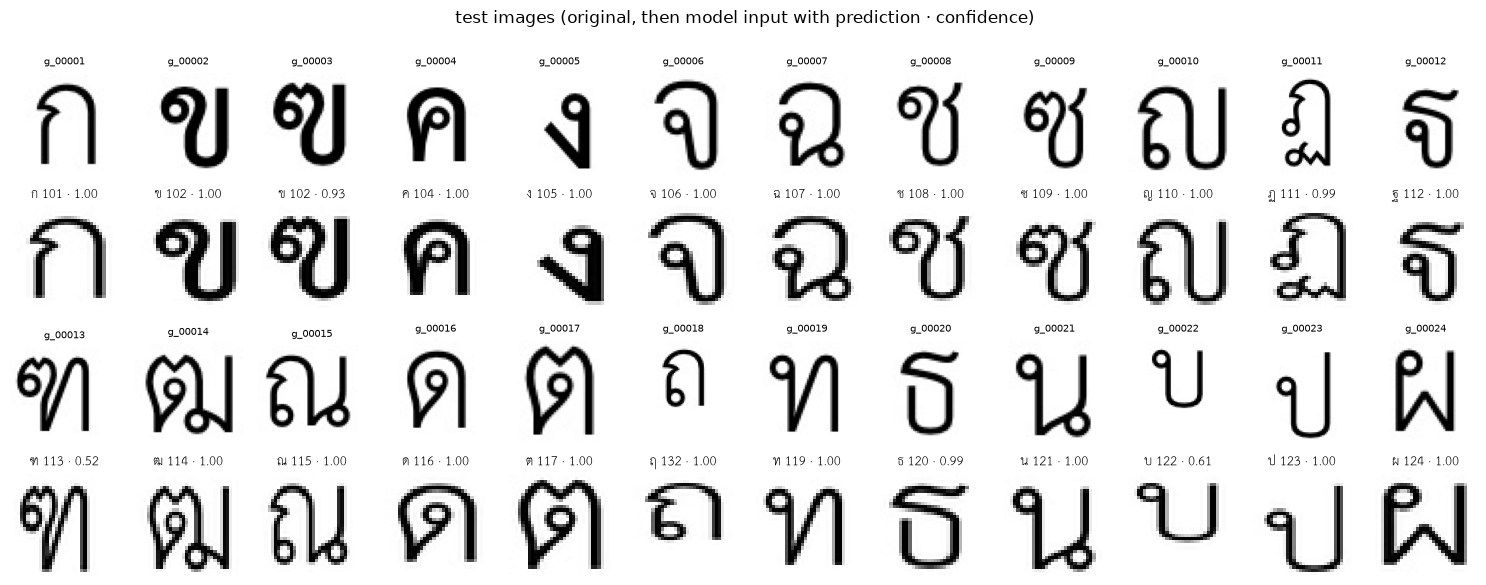

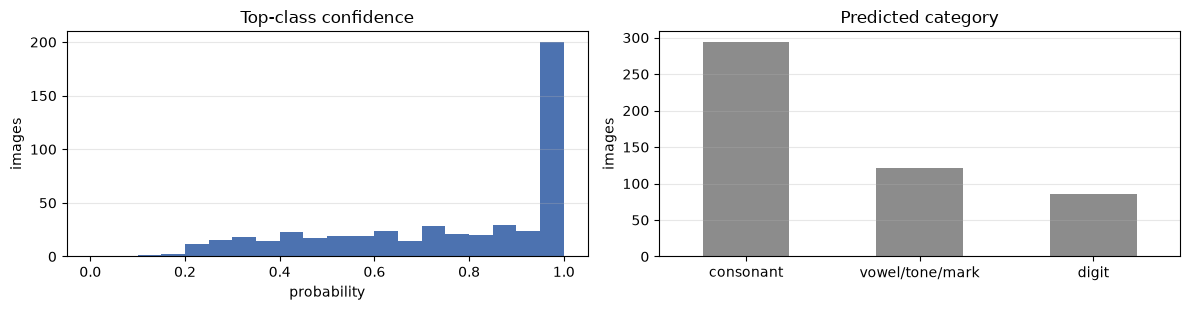

confidence ≥ 0.9: 44.8% of images · median 0.855


In [6]:
size, mode = pred.cfg["img_size"], pred.cfg["preprocess"]
N_SHOW, COLS = 24, 12

fig, ax = plt.subplots(2 * int(np.ceil(N_SHOW / COLS)), COLS, figsize=(1.25 * COLS, 2.9 * np.ceil(N_SHOW / COLS)))
for a in ax.ravel():
    a.axis("off")
for i, f in enumerate(paths[:N_SHOW]):
    r, c = 2 * (i // COLS), i % COLS
    with Image.open(f) as im:
        ax[r, c].imshow(im.convert("L"), cmap="gray", vmin=0, vmax=255)
    ax[r, c].set_title(f.stem[-7:], fontsize=7)
    ax[r + 1, c].imshow(load_test_image(f, size, mode)[0], cmap="gray", vmin=0, vmax=255)
    ax[r + 1, c].set_title(f"{chars[top_i[i, 0]]} {idx_to_id[top_i[i, 0]]} · {top_p[i, 0]:.2f}", fontproperties=THAI)
fig.suptitle("test images (original, then model input with prediction · confidence)", y=1.0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].hist(top_p[:, 0], np.linspace(0, 1, 21), color="#4C72B0")
ax[0].set(title="Top-class confidence", xlabel="probability", ylabel="images")
cat = pd.Series(idx_to_id[top_i[:, 0]]).str[0].map({"1": "consonant", "2": "vowel/tone/mark", "3": "digit"})
cat.value_counts().reindex(["consonant", "vowel/tone/mark", "digit"], fill_value=0).plot.bar(ax=ax[1], color="#8C8C8C", rot=0)
ax[1].set(title="Predicted category", ylabel="images")
for a in ax:
    a.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
print(f"confidence ≥ 0.9: {(top_p[:, 0] >= 0.9).mean():.1%} of images · median {np.median(top_p[:, 0]):.3f}")

the 24 least confident predictions (1st choice, then runner-up):


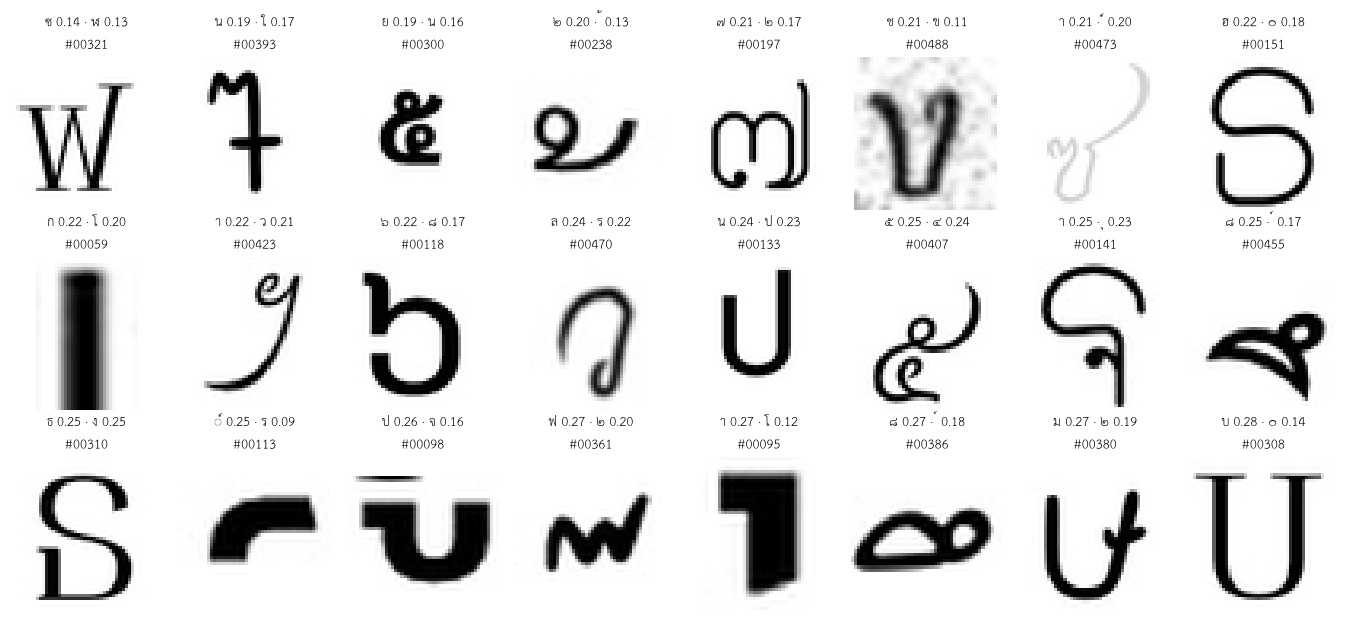

In [7]:
N_LOW, COLS = 24, 8
low = np.argsort(top_p[:, 0])[:N_LOW]
print(f"the {len(low)} least confident predictions (1st choice, then runner-up):")
fig, ax = plt.subplots(int(np.ceil(len(low) / COLS)), COLS, figsize=(1.7 * COLS, 2.1 * np.ceil(len(low) / COLS)), squeeze=False)
for a in ax.ravel():
    a.axis("off")
for a, i in zip(ax.ravel(), low, strict=False):
    a.imshow(load_test_image(paths[i], 48, "letterbox")[0], cmap="gray", vmin=0, vmax=255)
    a.set_title(f"{chars[top_i[i, 0]]} {top_p[i, 0]:.2f} · {chars[top_i[i, 1]]} {top_p[i, 1]:.2f}\n#{paths[i].stem.rsplit('_', 1)[-1]}",
                fontproperties=THAI)
plt.tight_layout()
plt.show()

## 6 · Score (only when the sheet has labels)

The sheet is scored per image: 1 point when our `class_id` equals `gt_class_id`, 0 when it differs
or is blank. This cell runs only if every `gt_class_id` in the template is a real class_id, e.g. on a
rehearsal set or once the answers are released. The blank sheet we download is skipped.

In [8]:
valid = set(class_ids.values())
if len(template) and template.gt_class_id.isin(valid).all():
    ok = sub[GROUP].to_numpy() == template.gt_class_id.to_numpy()
    print(f"score: {ok.sum()} / {len(ok)}  ({ok.mean():.2%})")
    wrong = detail[~ok].assign(gt_class_id=template.gt_class_id[~ok], gt_label=template.gt_label[~ok])
    display(wrong[["gt_path", "gt_label", "gt_class_id", "class_id_1", "char_1", "p_1", "class_id_2", "char_2", "p_2"]].head(30))
else:
    print("skipped: the template has no ground-truth class_ids")

skipped: the template has no ground-truth class_ids
